<a href="https://colab.research.google.com/github/gonzH/ifes-redes-neurais-artificiais/blob/main/trab01_backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Prencha suas informações: { display-mode: "form" }

nome_completo = 'Hellesandro Gonzaga de Carvalho'  # @param {type: "string"}
matricula     = '20251MCPA0110'  # @param {type: "string"}

data = '2026-06-12'  # @param {type: "date"}
# @markdown ---

## Tarefa:

> Você deve implementar e testar um Multi Layer Perceptron (MLP) e comparar o resultado dele com o implementado no Scikit-Learn.

> O seu MLP deve aceitar parâmetros para definir a quantidade de camadas, assim como a quantidade de neurônios em cada camada e a função de ativação que será utilizada em cada camada.

In [ ]:
# Utilities
def defineAxes(X):
  offset = 0.5
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)

def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

def include_bias(X):
  '''Adds a bias term (column of ones) to the input matrix X'''
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  '''Returns -1 for negative values and 1 for non-negative values'''
  return (a>=0)*2-1

ACTIVATION_FUNCS = {
    'tanh': tanh
}

DERIV_ACTIVATION_FUNCS = {
    'tanh': dtanh
}

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

class MultiLayer(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10000, learning_rate=0.01,
               n_hidden=[2], hidden_activation_funcs=None, verbose=False):

    # ini hyperparams and stucture
    self.max_iter = max_iter
    self.learning_rate = learning_rate
    self.n_hidden = n_hidden # list of neuron counts for each hidden layer
    self.verbose = verbose # print progress

    # set activation functions for hidden layers
    if hidden_activation_funcs is None:
        self.hidden_activation_funcs = ['tanh'] * len(n_hidden)
    else:
        if len(hidden_activation_funcs) != len(n_hidden):
            raise ValueError("Number of hidden_activation_funcs must match number of hidden layers.")
        self.hidden_activation_funcs = hidden_activation_funcs

  def forward(self, X):
    '''Performs the forward pass through the network'''

    self.A = [] # stores activated outputs (including bias) for each layer
    self.Z = [] # stores weighted sums (before activation) for each layer
    AUX = X.copy() # current layer input

    # iterate through hidden layers
    for i, W in enumerate(self.Ws[:-1]): # self.Ws stores weight matrices
      self.A.append(include_bias(AUX)) # add bias to current input and store
      self.Z.append(self.A[-1] @ W) # calculate weighted sum (Z)

      # apply activation and update input for next layer
      AUX = ACTIVATION_FUNCS[self.hidden_activation_funcs[i]](self.Z[-1])

    # output layer (linear activation for logits)
    self.A.append(include_bias(AUX)) # add bias to input of output layer
    self.Z.append(self.A[-1] @ self.Ws[-1]) # calculate weighted sum for output
    return self.Z[-1] # return raw output (logits)

  def backward(self, y, logits):
    '''Performs the backward pass (backpropagation) to update weights'''

    grads = [] # stores gradients for each weight matrix
    output_delta = logits - y # error at the output layer
    grads.insert(0, self.A[-1].T @ output_delta) # gradient for output layer weights

    # iterate backwards through hidden layers to calculate gradients
    for i in range(len(self.Ws)-2, -1, -1): # from the last hidden layer's weights down to the first
      # get the derivative of the activation function for the current hidden layer
      deriv_func = DERIV_ACTIVATION_FUNCS[self.hidden_activation_funcs[i]]
      # calculate delta for the current hidden layer
      input_delta = output_delta @ self.Ws[i+1][1:].T * deriv_func(self.Z[i])
      grads.insert(0, self.A[i].T @ input_delta) # gradient for current hidden layer weights
      output_delta = input_delta.copy() # propagate delta to the previous layer

    # update weights using calculated gradients and learning rate
    for i in range(len(self.Ws)):
      self.Ws[i] -= grads[i] * self.learning_rate

  def fit(self, X, y):
    '''trains the neural network'''

    if len(y.shape) == 1:
      y = y.reshape(-1, 1) # reshape y to be a column vector if needed

    # standardize X to prevent numerical issues during training
    self.scaler = StandardScaler()
    X_scaled = self.scaler.fit_transform(X)

    self.Ws = [] # list to store weight matrices
    previous_output = X_scaled.shape[1] # number of features in the input layer

    for n in self.n_hidden:
      # initialize weights with a small random normal distribution for stability
      self.Ws.append(np.random.normal(0, 0.1, (previous_output+1, n)))
      previous_output = n # update previous_output for the next layer

    # initialize weights for the output layer
    self.Ws.append(np.random.normal(0, 0.1, (previous_output+1, y.shape[1])))

    # training loop
    for epoch in range(self.max_iter):
      logits = self.forward(X_scaled)
      self.backward(y, logits)

      # print training progress if verbose is True
      if self.verbose and epoch % (self.max_iter // 10) == 0:
          ypred = sign(logits)
          accuracy = accuracy_score(y, ypred)
          print(f"Epoch {epoch}/{self.max_iter}, Accuracy: {accuracy:.4f}")

    return self # return the trained model

  def predict(self, X):
    # makes predictions using the trained neural network
    X_scaled = self.scaler.transform(X) # scale new data using the same scaler fitted during training
    logits = self.forward(X_scaled)
    ypred = sign(logits) # apply sign function to get binary predictions
    return ypred

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


MultiLayer (Custom) with tanh
Epoch 0/10000, Accuracy: 0.5000
Epoch 1000/10000, Accuracy: 1.0000
Epoch 2000/10000, Accuracy: 1.0000
Epoch 3000/10000, Accuracy: 1.0000
Epoch 4000/10000, Accuracy: 1.0000
Epoch 5000/10000, Accuracy: 1.0000
Epoch 6000/10000, Accuracy: 1.0000
Epoch 7000/10000, Accuracy: 1.0000
Epoch 8000/10000, Accuracy: 1.0000
Epoch 9000/10000, Accuracy: 1.0000
Accuracy (Custom MLP, tanh): 1.0000


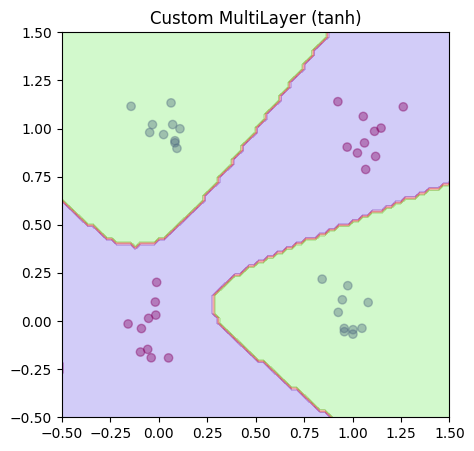

In [ ]:
X, y = makeLogicalDataset()

print("\nMultiLayer (Custom) with tanh")
model_custom_tanh = MultiLayer(max_iter=10000, learning_rate=0.01, n_hidden=[5], hidden_activation_funcs=['tanh'], verbose=True)
model_custom_tanh.fit(X, y)
ypred_custom_tanh = model_custom_tanh.predict(X)

print(f"Accuracy (Custom MLP, tanh): {accuracy_score(y, ypred_custom_tanh):.4f}")
plotDataset(X, y)
plotPredictions(model_custom_tanh, X)
plt.title("Custom MultiLayer (tanh)")
plt.show()


Scikit-learn MLPClassifier
Iteration 1, loss = 0.69142535
Iteration 2, loss = 0.68201335
Iteration 3, loss = 0.67324347
Iteration 4, loss = 0.66510981
Iteration 5, loss = 0.65760031
Iteration 6, loss = 0.65069465
Iteration 7, loss = 0.64435988
Iteration 8, loss = 0.63854912
Iteration 9, loss = 0.63320539
Iteration 10, loss = 0.62826915
Iteration 11, loss = 0.62368359
Iteration 12, loss = 0.61939588
Iteration 13, loss = 0.61535696
Iteration 14, loss = 0.61152150
Iteration 15, loss = 0.60784687
Iteration 16, loss = 0.60429119
Iteration 17, loss = 0.60081439
Iteration 18, loss = 0.59738147
Iteration 19, loss = 0.59396262
Iteration 20, loss = 0.59053245
Iteration 21, loss = 0.58706984
Iteration 22, loss = 0.58355767
Iteration 23, loss = 0.57998247
Iteration 24, loss = 0.57633405
Iteration 25, loss = 0.57260503
Iteration 26, loss = 0.56879054
Iteration 27, loss = 0.56488792
Iteration 28, loss = 0.56089645
Iteration 29, loss = 0.55681697
Iteration 30, loss = 0.55265143
Iteration 31, loss = 

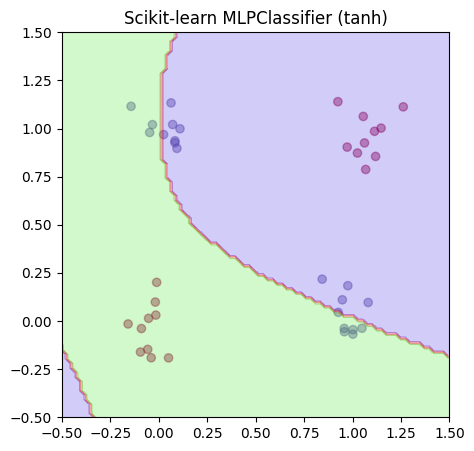

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

print("\nScikit-learn MLPClassifier")
scaler_sklearn = StandardScaler()
X_scaled_sklearn = scaler_sklearn.fit_transform(X)

mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(5,), # one hidden layer with 5 neurons
    activation='tanh',       # match custom MLP's default activation
    max_iter=10000,          # number of epochs
    learning_rate_init=0.01, # initial learning rate
    random_state=42,
    verbose=True
)

mlp_sklearn.fit(X_scaled_sklearn, y.ravel()) # y needs to be 1D for sklearn's fit
ypred_sklearn = mlp_sklearn.predict(X_scaled_sklearn)

print(f"Accuracy (Scikit-learn MLP, tanh): {accuracy_score(y, ypred_sklearn):.4f}")
plotDataset(X, y)
plotPredictions(mlp_sklearn, X)
plt.title("Scikit-learn MLPClassifier (tanh)")
plt.show()